# Week 2 EDA Notebook: Synthetic Aido Rover Fleet Telemetry

This notebook performs exploratory data analysis on a synthetic Aido Rover fleet telemetry dataset. The dataset is structured as a panel DataFrame indexed by `unit_id` and `timestamp`, analogous to an equity panel indexed by `stock_id` and `date`.

The analysis includes basic data inspection, missingness checks, stationarity testing, rolling-window metrics, inter-unit correlation, and cross-sectional percentile ranking.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_PATH = "data/w02_telemetry_sample.parquet"

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
print("Index names:", df.index.names)

df.head()

Shape: (172800, 23)
Index names: ['unit_id', 'timestamp']


speed  cli_horizon  battery_voltage  \
unit_id timestamp                                                     
AR_000  2026-06-15 00:00:00  0.521179     5.083757        23.908513   
        2026-06-15 00:01:00  0.365070     4.586227        24.003670   
        2026-06-15 00:02:00  0.278834     6.368278        23.969681   
        2026-06-15 00:03:00  0.198349     5.886972        23.869116   
        2026-06-15 00:04:00  0.595951     5.637736        23.999075   

                             battery_soc  gps_fix_quality       rssi  \
unit_id timestamp                                                      
AR_000  2026-06-15 00:00:00    99.704469              3.0 -55.822106   
        2026-06-15 00:01:00    99.701946              3.0 -58.794668   
        2026-06-15 00:02:00    99.699698              3.0 -64.227990   
        2026-06-15 00:03:00    99.697698              3.0 -64.411446   
        2026-06-15 00:04:00    99.694652              3.0 -58.391528   

                             task_success  imu_accel_x  imu_accel_y  \
unit_id timestamp                                                     
AR_000  2026-06-15 00:00:00             0     0.074280    -0.010821   
        2026-06-15 00:01:00             1     0.071828     0.051007   
        2026-06-15 00:02:00             1    -0.046621    -0.053818   
        2026-06-15 00:03:00             1    -0.048077     0.023400   
        2026-06-15 00:04:00             1     0.195469     0.048882   

                             imu_accel_z  ...  motor_current_1  \
unit_id timestamp                         ...                    
AR_000  2026-06-15 00:00:00     9.776786  ...         3.242784   
        2026-06-15 00:01:00     9.820906  ...         3.343849   
        2026-06-15 00:02:00     9.834250  ...         2.111588   
        2026-06-15 00:03:00     9.765833  ...         2.365457   
        2026-06-15 00:04:00     9.827407  ...         3.154179   

                             motor_current_2  motor_current_3  \
unit_id timestamp                                               
AR_000  2026-06-15 00:00:00         3.793410         3.568109   
        2026-06-15 00:01:00         2.799251         2.780257   
        2026-06-15 00:02:00         2.879929         3.098270   
        2026-06-15 00:03:00         2.754984         2.736275   
        2026-06-15 00:04:00         3.519160         3.656680   

                             motor_current_4  joint_angle_1  joint_angle_2  \
unit_id timestamp                                                            
AR_000  2026-06-15 00:00:00         3.407211      18.748265      21.830432   
        2026-06-15 00:01:00         3.299433      19.933469      17.131750   
        2026-06-15 00:02:00         2.548003      18.626577      20.727388   
        2026-06-15 00:03:00         2.367367      19.400140      17.245609   
        2026-06-15 00:04:00         4.084969      18.187356      20.257118   

                             joint_angle_3  joint_angle_4  joint_angle_5  \
unit_id timestamp                                                          
AR_000  2026-06-15 00:00:00       6.141313     -11.724873     -15.732016   
        2026-06-15 00:01:00       3.937620     -14.285341     -18.574714   
        2026-06-15 00:02:00       3.440113     -12.964167     -19.025561   
        2026-06-15 00:03:00       3.153903     -16.167716     -18.772324   
        2026-06-15 00:04:00       2.770112     -11.142900     -16.530379   

                             joint_angle_6  
unit_id timestamp                           
AR_000  2026-06-15 00:00:00       1.196158  
        2026-06-15 00:01:00      -4.215946  
        2026-06-15 00:02:00      -4.734702  
        2026-06-15 00:03:00      -2.705193  
        2026-06-15 00:04:00      -5.142254  

[5 rows x 23 columns]

## 1. Basic Data Inspection

This section checks the structure, columns, data types, and summary statistics of the synthetic telemetry dataset.

In [3]:
# Check column names
df.columns.tolist()

['speed',
 'cli_horizon',
 'battery_voltage',
 'battery_soc',
 'gps_fix_quality',
 'rssi',
 'task_success',
 'imu_accel_x',
 'imu_accel_y',
 'imu_accel_z',
 'imu_gyro_x',
 'imu_gyro_y',
 'imu_gyro_z',
 'motor_current_1',
 'motor_current_2',
 'motor_current_3',
 'motor_current_4',
 'joint_angle_1',
 'joint_angle_2',
 'joint_angle_3',
 'joint_angle_4',
 'joint_angle_5',
 'joint_angle_6']

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 172800 entries, ('AR_000', Timestamp('2026-06-15 00:00:00')) to ('AR_039', Timestamp('2026-06-17 23:59:00'))
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   speed            172800 non-null  float64
 1   cli_horizon      172800 non-null  float64
 2   battery_voltage  172800 non-null  float64
 3   battery_soc      172800 non-null  float64
 4   gps_fix_quality  172787 non-null  float64
 5   rssi             171145 non-null  float64
 6   task_success     172800 non-null  int64  
 7   imu_accel_x      171928 non-null  float64
 8   imu_accel_y      171928 non-null  float64
 9   imu_accel_z      171928 non-null  float64
 10  imu_gyro_x       171928 non-null  float64
 11  imu_gyro_y       171928 non-null  float64
 12  imu_gyro_z       171928 non-null  float64
 13  motor_current_1  172310 non-null  float64
 14  motor_current_2  172310 non-null  float64
 15  motor_current_3

In [5]:
# Summary statistics for numeric telemetry variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
speed,172800.0,1.308754,0.671870,0.000000,0.717426,1.299532,1.896325,3.365531
cli_horizon,172800.0,9.046408,2.950541,1.072791,6.406632,9.004908,11.667253,16.884307
battery_voltage,172800.0,23.631034,0.202959,22.817678,23.493817,23.641134,23.774976,24.264428
battery_soc,172800.0,92.617730,3.732202,81.310932,90.077373,92.842682,95.262486,100.000000
gps_fix_quality,172787.0,2.979240,0.142863,1.000000,3.000000,3.000000,3.000000,3.000000
rssi,171145.0,-52.439769,6.590411,-81.584391,-57.430946,-52.476630,-47.441727,-24.351806
task_success,172800.0,0.935347,0.245913,0.000000,1.000000,1.000000,1.000000,1.000000
imu_accel_x,171928.0,0.196376,0.129104,-0.306560,0.102486,0.195920,0.290526,0.730057
imu_accel_y,171928.0,-0.000008,0.060241,-0.291505,-0.039695,0.000097,0.039815,0.273909
imu_accel_z,171928.0,9.810077,0.050333,9.574285,9.776902,9.809918,9.843260,10.058861


In [6]:
n_units = df.index.get_level_values("unit_id").nunique()
n_timestamps = df.index.get_level_values("timestamp").nunique()

print("Number of rover units:", n_units)
print("Number of timestamps:", n_timestamps)
print("Total panel observations:", len(df))

Number of rover units: 40
Number of timestamps: 4320
Total panel observations: 172800


## 2. Missingness Check

This section examines missing-value patterns across telemetry channels. Missingness is expected to appear in GPS, RSSI, IMU, and motor-current channels because the generator intentionally simulates signal dropout and sensor gaps.

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean()
}).sort_values("missing_rate", ascending=False)

missing_summary

,missing_count,missing_rate
rssi,1655,0.009578
imu_gyro_y,872,0.005046
imu_accel_x,872,0.005046
imu_gyro_z,872,0.005046
imu_gyro_x,872,0.005046
imu_accel_z,872,0.005046
imu_accel_y,872,0.005046
motor_current_1,490,0.002836
motor_current_2,490,0.002836
motor_current_3,490,0.002836


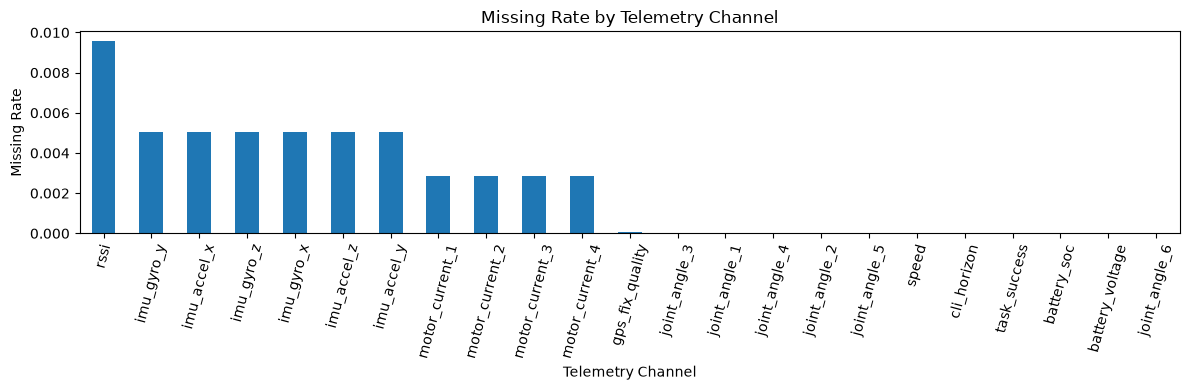

In [8]:
missing_summary["missing_rate"].plot(kind="bar", figsize=(12, 4))

plt.title("Missing Rate by Telemetry Channel")
plt.ylabel("Missing Rate")
plt.xlabel("Telemetry Channel")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Rows with at least one missing value: 3014
Columns with missing values: ['rssi', 'imu_gyro_y', 'imu_accel_x', 'imu_gyro_z', 'imu_gyro_x', 'imu_accel_z', 'imu_accel_y', 'motor_current_1', 'motor_current_2', 'motor_current_3', 'motor_current_4', 'gps_fix_quality']


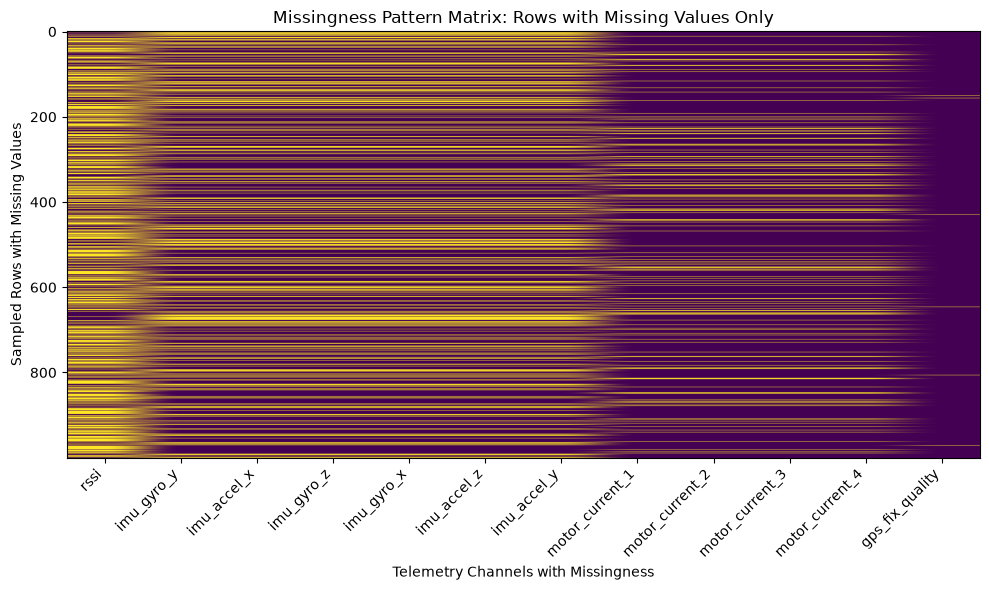

In [10]:
# Focus on columns that actually contain missing values
missing_cols = missing_summary[missing_summary["missing_count"] > 0].index.tolist()

# Keep only rows with at least one missing value in those columns
rows_with_missing = df.reset_index()
rows_with_missing = rows_with_missing[rows_with_missing[missing_cols].isna().any(axis=1)]

print("Rows with at least one missing value:", len(rows_with_missing))
print("Columns with missing values:", missing_cols)

# Sample from rows that actually have missingness
sample_missing_rows = rows_with_missing.sample(
    n=min(1000, len(rows_with_missing)),
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.imshow(sample_missing_rows[missing_cols].isna(), aspect="auto")
plt.title("Missingness Pattern Matrix: Rows with Missing Values Only")
plt.xlabel("Telemetry Channels with Missingness")
plt.ylabel("Sampled Rows with Missing Values")
plt.xticks(
    ticks=np.arange(len(missing_cols)),
    labels=missing_cols,
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [11]:
missing_pattern_counts = (
    df[missing_cols]
    .isna()
    .astype(int)
    .value_counts()
    .reset_index(name="count")
)

missing_pattern_counts.head(10)

,rssi,imu_gyro_y,imu_accel_x,imu_gyro_z,imu_gyro_x,imu_accel_z,imu_accel_y,motor_current_1,motor_current_2,motor_current_3,motor_current_4,gps_fix_quality,count
0,0,0,0,0,0,0,0,0,0,0,0,0,169786
1,1,0,0,0,0,0,0,0,0,0,0,0,1640
2,0,1,1,1,1,1,1,0,0,0,0,0,862
3,0,0,0,0,0,0,0,1,1,1,1,0,483
4,0,0,0,0,0,0,0,0,0,0,0,1,13
5,1,1,1,1,1,1,1,0,0,0,0,0,9
6,1,0,0,0,0,0,0,1,1,1,1,0,6
7,0,1,1,1,1,1,1,1,1,1,1,0,1


In [12]:
missing_pattern_counts_clean = missing_pattern_counts.copy()

missing_pattern_counts_clean["missing_channels"] = missing_pattern_counts_clean[missing_cols].apply(
    lambda row: ", ".join(row.index[row == 1]),
    axis=1
)

missing_pattern_counts_clean = missing_pattern_counts_clean[
    ["missing_channels", "count"]
]
missing_pattern_counts_clean.head(10)

,missing_channels,count
0,,169786
1,rssi,1640
2,"imu_gyro_y, imu_accel_x, imu_gyro_z, imu_gyro_...",862
3,"motor_current_1, motor_current_2, motor_curren...",483
4,gps_fix_quality,13
5,"rssi, imu_gyro_y, imu_accel_x, imu_gyro_z, imu...",9
6,"rssi, motor_current_1, motor_current_2, motor_...",6
7,"imu_gyro_y, imu_accel_x, imu_gyro_z, imu_gyro_...",1


The full missingness matrix was visually sparse because the simulated missing rates are intentionally low. To make the structure easier to inspect, the matrix above focuses only on rows and telemetry channels that contain missing values.

The missingness is structured rather than purely random. RSSI has the highest missing rate and often appears independently. IMU acceleration and gyroscope channels tend to be missing together, which represents a block-level IMU sensor dropout. Motor-current channels also tend to be missing together, representing a temporary drive-current sensor gap. GPS fix quality has rare missingness under weak-signal conditions.

This resembles financial panel data where missing values often appear in structured groups, such as stale quotes, vendor field gaps, missing liquidity variables, or delayed reporting for specific securities.

## 3. ADF Stationarity Test

This section applies the Augmented Dickey-Fuller test to selected telemetry channels. The ADF test checks whether a time series is stationary. In financial data, price-like series are often non-stationary, while return-like or sensor-noise-like series are more likely to be stationary.

For this telemetry dataset, battery SoC is expected to behave more like a price-level or drawdown series because it trends downward during operation. Motor current, RSSI, and IMU channels are expected to be more stationary around operating regimes.

In [13]:
def run_adf_test(series, max_points=5000):
    """
    Run ADF test on a single time series.
    max_points is used to keep the test lightweight for notebook execution.
    """

    clean_series = series.dropna()

    if len(clean_series) > max_points:
        clean_series = clean_series.iloc[:max_points]

    result = adfuller(clean_series)

    return {
        "adf_statistic": result[0],
        "p_value": result[1],
        "used_lags": result[2],
        "n_obs": result[3],
        "stationary_at_5pct": result[1] < 0.05
    }

In [14]:
selected_unit = "AR_000"

unit_df = df.loc[selected_unit].copy()

adf_channels = [
    "battery_soc",
    "motor_current_1",
    "rssi",
    "imu_accel_x",
    "joint_angle_1"
]

adf_results = []

for col in adf_channels:
    result = run_adf_test(unit_df[col])
    result["unit_id"] = selected_unit
    result["channel"] = col
    adf_results.append(result)

adf_results_df = pd.DataFrame(adf_results)
adf_results_df = adf_results_df[
    ["unit_id", "channel", "adf_statistic", "p_value", "used_lags", "n_obs", "stationary_at_5pct"]
]

adf_results_df

,unit_id,channel,adf_statistic,p_value,used_lags,n_obs,stationary_at_5pct
0,AR_000,battery_soc,-1.527630,0.519802,29,4290,False
1,AR_000,motor_current_1,-1.095683,0.716790,30,4284,False
2,AR_000,rssi,-1.803882,0.378536,30,4252,False
3,AR_000,imu_accel_x,-1.927473,0.319249,30,4266,False
4,AR_000,joint_angle_1,-0.912148,0.783946,17,4302,False


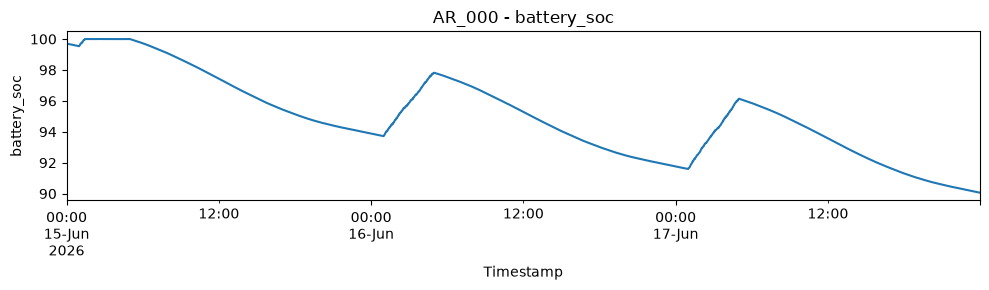

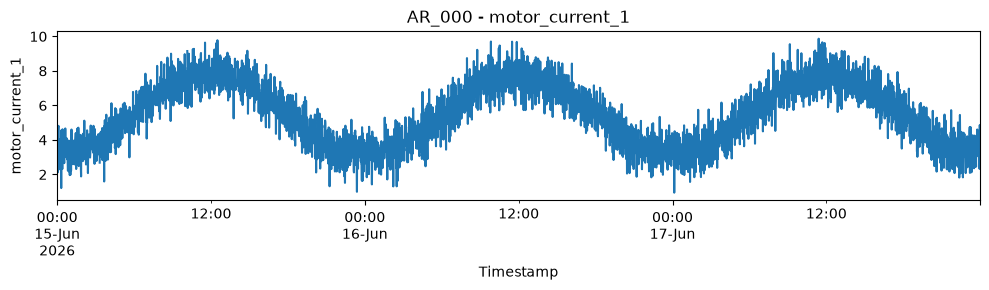

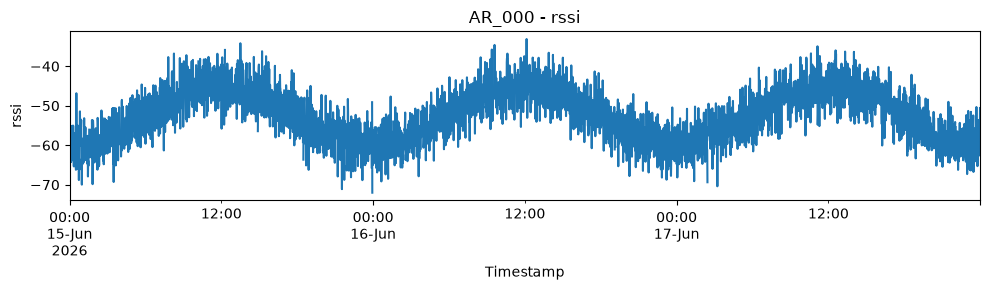

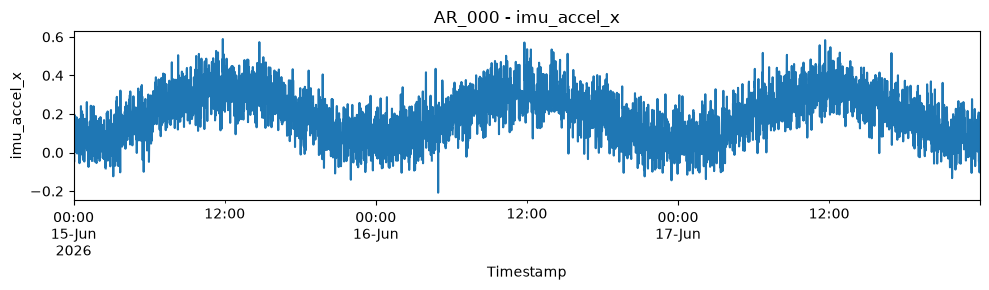

In [15]:
plot_channels = ["battery_soc", "motor_current_1", "rssi", "imu_accel_x"]

for col in plot_channels:
    plt.figure(figsize=(10, 3))
    unit_df[col].plot()
    plt.title(f"{selected_unit} - {col}")
    plt.xlabel("Timestamp")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

The ADF results suggest that the selected telemetry channels are not stationary at the 5% level for unit `AR_000`. This is expected for `battery_soc`, which behaves like a level or drawdown variable because it trends downward during active operation and partially recovers during charging periods.

The other channels, including motor current, RSSI, IMU acceleration, and joint angle, also fail the ADF test in this sample. This is likely because the synthetic generator includes a daily operating cycle: rover activity, speed, motor load, signal strength, and sensor movement vary systematically across the day. Therefore, these telemetry channels are not purely stationary noise processes; they contain operating-regime structure.

This mirrors a common workflow in financial time-series analysis. Before fitting a time-series model, price-like or regime-driven variables often need transformation, de-trending, differencing, or rolling normalization. In this project, the ADF test helps identify which telemetry channels should be treated carefully before modeling.

## 4. Rolling-Window Metrics

This section computes rolling-window telemetry metrics using the same logic as rolling financial indicators. The assignment requires 7-day rolling mean and standard deviation for battery SoC and motor current. Although the sample file contains 3 days of data for lightweight GitHub submission, the code uses a 7-day rolling window and will work directly on a longer 30-day dataset.

In [18]:
# Rolling 7-day metrics by rover unit
# This version avoids pandas MultiIndex rolling compatibility issues.

df_rolling = df.reset_index().sort_values(["unit_id", "timestamp"]).copy()

rolling_parts = []

for unit_id, group in df_rolling.groupby("unit_id"):
    group = group.sort_values("timestamp").copy()
    group = group.set_index("timestamp")
    group["battery_soc_roll_mean_7d"] = group["battery_soc"].rolling("7D").mean()
    group["battery_soc_roll_std_7d"] = group["battery_soc"].rolling("7D").std()
    group["motor_current_1_roll_mean_7d"] = group["motor_current_1"].rolling("7D").mean()
    group["motor_current_1_roll_std_7d"] = group["motor_current_1"].rolling("7D").std()
    group["unit_id"] = unit_id
    rolling_parts.append(group.reset_index())

df_rolling = (
    pd.concat(rolling_parts, ignore_index=True)
    .set_index(["unit_id", "timestamp"])
    .sort_index()
)

df_rolling[
    [
        "battery_soc",
        "battery_soc_roll_mean_7d",
        "battery_soc_roll_std_7d",
        "motor_current_1",
        "motor_current_1_roll_mean_7d",
        "motor_current_1_roll_std_7d",
    ]
].head(10)

battery_soc  battery_soc_roll_mean_7d  \
unit_id timestamp                                                    
AR_000  2026-06-15 00:00:00    99.704469                 99.704469   
        2026-06-15 00:01:00    99.701946                 99.703207   
        2026-06-15 00:02:00    99.699698                 99.702038   
        2026-06-15 00:03:00    99.697698                 99.700953   
        2026-06-15 00:04:00    99.694652                 99.699693   
        2026-06-15 00:05:00    99.691668                 99.698355   
        2026-06-15 00:06:00    99.687503                 99.696805   
        2026-06-15 00:07:00    99.685493                 99.695391   
        2026-06-15 00:08:00    99.682333                 99.693940   
        2026-06-15 00:09:00    99.680181                 99.692564   

                             battery_soc_roll_std_7d  motor_current_1  \
unit_id timestamp                                                       
AR_000  2026-06-15 00:00:00                      NaN         3.242784   
        2026-06-15 00:01:00                 0.001784         3.343849   
        2026-06-15 00:02:00                 0.002387         2.111588   
        2026-06-15 00:03:00                 0.002916         2.365457   
        2026-06-15 00:04:00                 0.003784         3.154179   
        2026-06-15 00:05:00                 0.004710         4.614924   
        2026-06-15 00:06:00                 0.005943         4.815997   
        2026-06-15 00:07:00                 0.006802         2.974467   
        2026-06-15 00:08:00                 0.007709         3.647329   
        2026-06-15 00:09:00                 0.008471         2.296263   

                             motor_current_1_roll_mean_7d  \
unit_id timestamp                                           
AR_000  2026-06-15 00:00:00                      3.242784   
        2026-06-15 00:01:00                      3.293317   
        2026-06-15 00:02:00                      2.899407   
        2026-06-15 00:03:00                      2.765920   
        2026-06-15 00:04:00                      2.843571   
        2026-06-15 00:05:00                      3.138797   
        2026-06-15 00:06:00                      3.378397   
        2026-06-15 00:07:00                      3.327906   
        2026-06-15 00:08:00                      3.363397   
        2026-06-15 00:09:00                      3.256684   

                             motor_current_1_roll_std_7d  
unit_id timestamp                                         
AR_000  2026-06-15 00:00:00                          NaN  
        2026-06-15 00:01:00                     0.071464  
        2026-06-15 00:02:00                     0.684140  
        2026-06-15 00:03:00                     0.619118  
        2026-06-15 00:04:00                     0.563586  
        2026-06-15 00:05:00                     0.881505  
        2026-06-15 00:06:00                     1.024402  
        2026-06-15 00:07:00                     0.959104  
        2026-06-15 00:08:00                     0.903456  
        2026-06-15 00:09:00                     0.916197

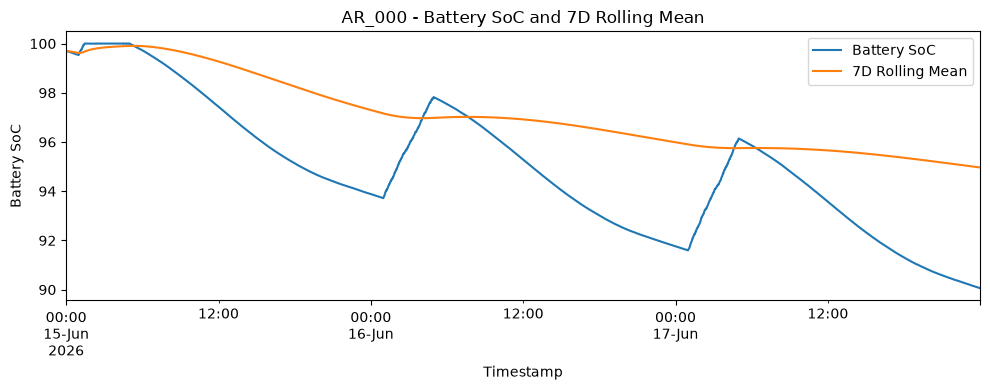

In [19]:
selected_unit = "AR_000"

unit_roll = df_rolling.loc[selected_unit].copy()

plt.figure(figsize=(10, 4))
unit_roll["battery_soc"].plot(label="Battery SoC")
unit_roll["battery_soc_roll_mean_7d"].plot(label="7D Rolling Mean")

plt.title(f"{selected_unit} - Battery SoC and 7D Rolling Mean")
plt.xlabel("Timestamp")
plt.ylabel("Battery SoC")
plt.legend()
plt.tight_layout()
plt.show()

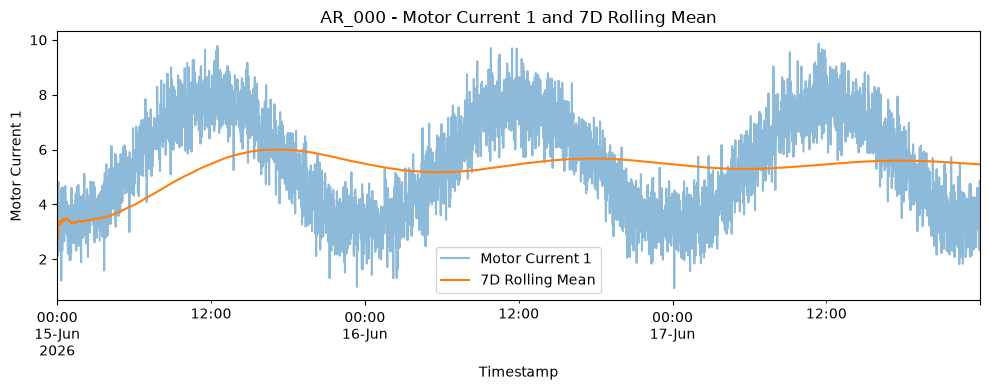

In [20]:
plt.figure(figsize=(10, 4))
unit_roll["motor_current_1"].plot(label="Motor Current 1", alpha=0.5)
unit_roll["motor_current_1_roll_mean_7d"].plot(label="7D Rolling Mean")

plt.title(f"{selected_unit} - Motor Current 1 and 7D Rolling Mean")
plt.xlabel("Timestamp")
plt.ylabel("Motor Current 1")
plt.legend()
plt.tight_layout()
plt.show()

The rolling-window metrics smooth short-term telemetry noise and reveal slower operating trends. For battery SoC, the rolling mean captures the gradual depletion and recharge cycle, similar to a smoothed price level or drawdown metric in finance. For motor current, the rolling mean captures persistent load regimes, while the rolling standard deviation is analogous to rolling volatility.

Although this sample dataset contains only 3 days of observations for lightweight GitHub submission, the same code uses a 7-day rolling window and can be applied directly to the full 30-day synthetic telemetry panel.

## 5. Cross-Sectional Percentile Ranking

This section implements the Guotai Haitong-style cross-sectional ranking methodology. At each timestamp, every rover is ranked against the fleet based on its current KPI value. This is structurally similar to ranking stocks by valuation or factor metrics within a sector at each date.

Here, the selected KPIs are battery SoC and motor current. A high motor-current percentile means the rover is drawing more current than most other units at the same timestamp. A low battery-SoC percentile means the rover has lower remaining battery than most of the fleet.

In [21]:
# Cross-sectional percentile ranking at each timestamp
df_ranked = df_rolling.reset_index().sort_values(["timestamp", "unit_id"]).copy()

rank_kpis = [
    "battery_soc",
    "motor_current_1",
    "rssi",
    "task_success"
]

for col in rank_kpis:
    df_ranked[f"{col}_cs_pct_rank"] = (
        df_ranked
        .groupby("timestamp")[col]
        .rank(pct=True)
    )

df_ranked = df_ranked.set_index(["unit_id", "timestamp"]).sort_index()

df_ranked[
    [
        "battery_soc",
        "battery_soc_cs_pct_rank",
        "motor_current_1",
        "motor_current_1_cs_pct_rank",
        "rssi",
        "rssi_cs_pct_rank",
        "task_success",
        "task_success_cs_pct_rank",
    ]
].head(10)

battery_soc  battery_soc_cs_pct_rank  \
unit_id timestamp                                                   
AR_000  2026-06-15 00:00:00    99.704469                     0.95   
        2026-06-15 00:01:00    99.701946                     0.95   
        2026-06-15 00:02:00    99.699698                     0.95   
        2026-06-15 00:03:00    99.697698                     0.95   
        2026-06-15 00:04:00    99.694652                     0.95   
        2026-06-15 00:05:00    99.691668                     0.95   
        2026-06-15 00:06:00    99.687503                     0.95   
        2026-06-15 00:07:00    99.685493                     0.95   
        2026-06-15 00:08:00    99.682333                     0.95   
        2026-06-15 00:09:00    99.680181                     0.95   

                             motor_current_1  motor_current_1_cs_pct_rank  \
unit_id timestamp                                                           
AR_000  2026-06-15 00:00:00         3.242784                     0.475000   
        2026-06-15 00:01:00         3.343849                     0.525000   
        2026-06-15 00:02:00         2.111588                     0.051282   
        2026-06-15 00:03:00         2.365457                     0.175000   
        2026-06-15 00:04:00         3.154179                     0.384615   
        2026-06-15 00:05:00         4.614924                     1.000000   
        2026-06-15 00:06:00         4.815997                     0.950000   
        2026-06-15 00:07:00         2.974467                     0.350000   
        2026-06-15 00:08:00         3.647329                     0.692308   
        2026-06-15 00:09:00         2.296263                     0.100000   

                                  rssi  rssi_cs_pct_rank  task_success  \
unit_id timestamp                                                        
AR_000  2026-06-15 00:00:00 -55.822106          0.846154             0   
        2026-06-15 00:01:00 -58.794668          0.600000             1   
        2026-06-15 00:02:00 -64.227990          0.150000             1   
        2026-06-15 00:03:00 -64.411446          0.150000             1   
        2026-06-15 00:04:00 -58.391528          0.525000             1   
        2026-06-15 00:05:00 -55.090326          0.950000             1   
        2026-06-15 00:06:00 -64.236775          0.100000             0   
        2026-06-15 00:07:00        NaN               NaN             1   
        2026-06-15 00:08:00 -58.896890          0.575000             1   
        2026-06-15 00:09:00 -60.686983          0.410256             1   

                             task_success_cs_pct_rank  
unit_id timestamp                                      
AR_000  2026-06-15 00:00:00                    0.0500  
        2026-06-15 00:01:00                    0.5750  
        2026-06-15 00:02:00                    0.5500  
        2026-06-15 00:03:00                    0.5250  
        2026-06-15 00:04:00                    0.5500  
        2026-06-15 00:05:00                    0.5375  
        2026-06-15 00:06:00                    0.0500  
        2026-06-15 00:07:00                    0.5250  
        2026-06-15 00:08:00                    0.5250  
        2026-06-15 00:09:00                    0.5250

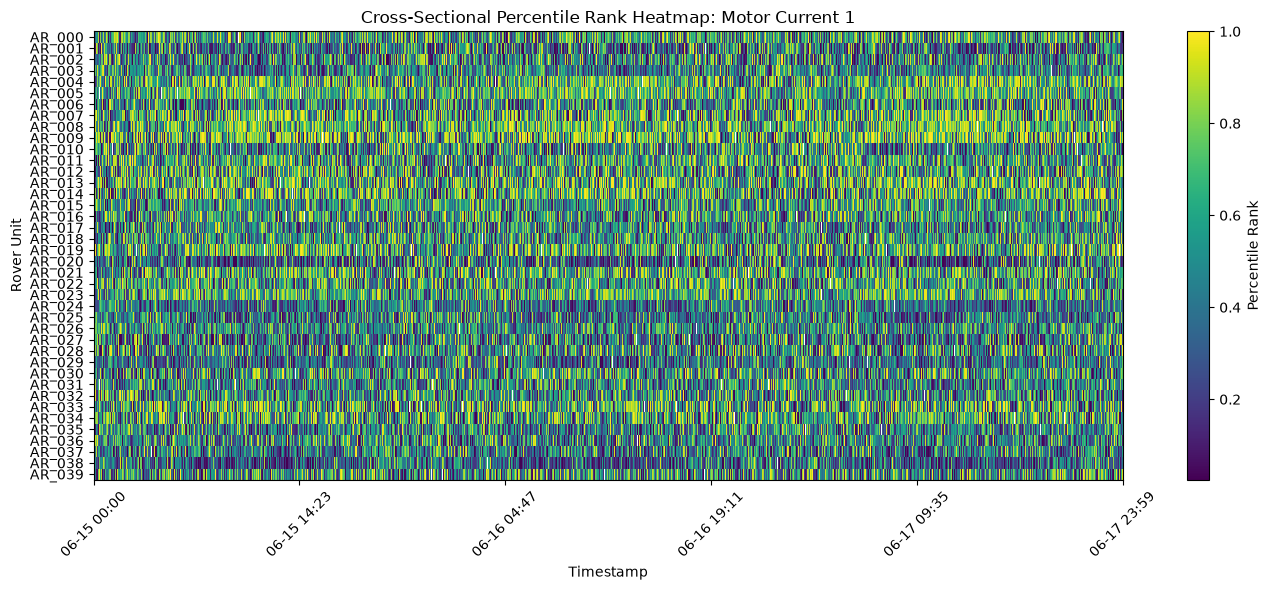

In [22]:
# Heatmap of cross-sectional percentile ranks
# Rows = rover units, columns = timestamps, values = percentile ranks

heatmap_kpi = "motor_current_1_cs_pct_rank"

rank_heatmap = (
    df_ranked
    .reset_index()
    .pivot(index="unit_id", columns="timestamp", values=heatmap_kpi)
)

plt.figure(figsize=(14, 6))
plt.imshow(rank_heatmap, aspect="auto", interpolation="nearest")
plt.title("Cross-Sectional Percentile Rank Heatmap: Motor Current 1")
plt.xlabel("Timestamp")
plt.ylabel("Rover Unit")
plt.colorbar(label="Percentile Rank")

# Reduce x-axis labels to avoid clutter
tick_positions = np.linspace(0, rank_heatmap.shape[1] - 1, 6, dtype=int)

tick_labels = [
    rank_heatmap.columns[i].strftime("%m-%d %H:%M")
    for i in tick_positions
]

plt.xticks(tick_positions, tick_labels, rotation=45)
plt.yticks(
    ticks=np.arange(rank_heatmap.shape[0]),
    labels=rank_heatmap.index
)

plt.tight_layout()
plt.show()

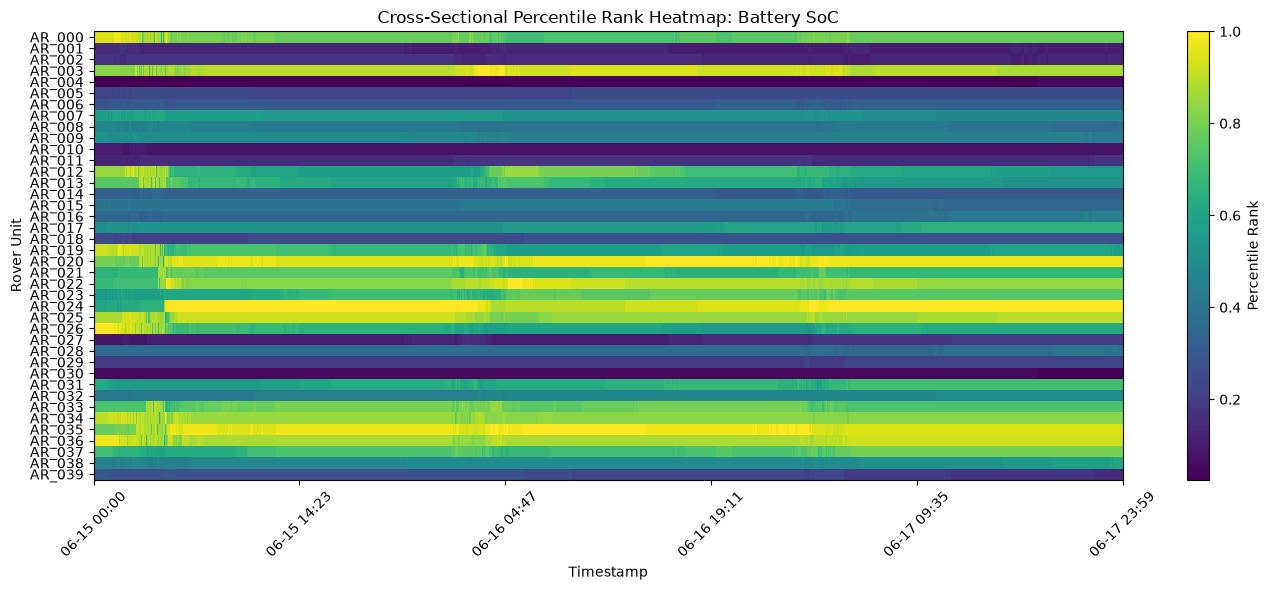

In [23]:
heatmap_kpi = "battery_soc_cs_pct_rank"

rank_heatmap = (
    df_ranked
    .reset_index()
    .pivot(index="unit_id", columns="timestamp", values=heatmap_kpi)
)

plt.figure(figsize=(14, 6))
plt.imshow(rank_heatmap, aspect="auto", interpolation="nearest")

plt.title("Cross-Sectional Percentile Rank Heatmap: Battery SoC")
plt.xlabel("Timestamp")
plt.ylabel("Rover Unit")
plt.colorbar(label="Percentile Rank")

tick_positions = np.linspace(0, rank_heatmap.shape[1] - 1, 6, dtype=int)
tick_labels = [
    rank_heatmap.columns[i].strftime("%m-%d %H:%M")
    for i in tick_positions
]

plt.xticks(tick_positions, tick_labels, rotation=45)
plt.yticks(
    ticks=np.arange(rank_heatmap.shape[0]),
    labels=rank_heatmap.index
)

plt.tight_layout()
plt.show()

The cross-sectional percentile-rank heatmaps show each rover's relative position within the fleet at each timestamp.

The motor-current heatmap is relatively noisy because motor current responds quickly to speed, terrain resistance, and short-term load changes. This resembles high-frequency or short-horizon factor rankings in equity data, where relative ranks can change frequently across dates.

The battery-SoC heatmap has more persistent horizontal bands. This indicates that some rovers remain relatively high or low in battery percentile over time, reflecting unit-level differences such as battery health, efficiency, or operating load. This is analogous to persistent cross-sectional valuation or quality rankings in equity data.

Importantly, the percentile ranking is computed cross-sectionally within each timestamp using `groupby("timestamp").rank(pct=True)`, rather than globally across the entire panel.

## 6. Inter-Unit Correlation Heatmap

This section examines whether telemetry signals move together across rover units. The structure is similar to an equity correlation matrix, where stocks may co-move because of shared sector exposure, market beta, or common risk factors.

Here, motor current is used as the example KPI. If two rover units have highly correlated motor-current patterns, they may be exposed to similar workload cycles or shared operating regimes.

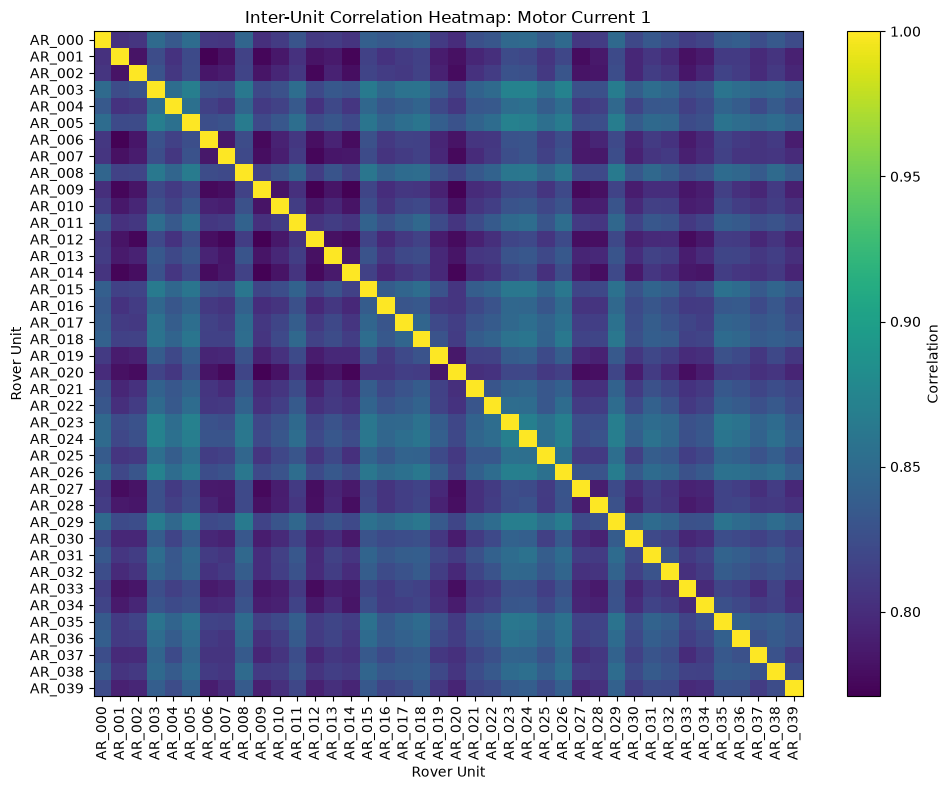

In [24]:
# Inter-unit correlation heatmap for motor current

corr_kpi = "motor_current_1"

motor_pivot = (
    df
    .reset_index()
    .pivot(index="timestamp", columns="unit_id", values=corr_kpi)
)
motor_corr = motor_pivot.corr()

plt.figure(figsize=(10, 8))
plt.imshow(motor_corr, aspect="auto", interpolation="nearest")

plt.title("Inter-Unit Correlation Heatmap: Motor Current 1")
plt.xlabel("Rover Unit")
plt.ylabel("Rover Unit")
plt.colorbar(label="Correlation")
plt.xticks(
    ticks=np.arange(len(motor_corr.columns)),
    labels=motor_corr.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(motor_corr.index)),
    labels=motor_corr.index
)

plt.tight_layout()
plt.show()

In [26]:
# Identify highly correlated rover pairs

corr_matrix = motor_corr.copy()

# Give index and columns different names to avoid reset_index name conflict

corr_matrix.index.name = "unit_1"
corr_matrix.columns.name = "unit_2"

upper_triangle_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

corr_pairs = (
    corr_matrix
    .where(upper_triangle_mask)
    .stack()
    .reset_index(name="correlation")
)

corr_pairs.sort_values("correlation", ascending=False).head(10)

,unit_1,unit_2,correlation
146,AR_003,AR_026,0.872232
144,AR_003,AR_024,0.872090
143,AR_003,AR_023,0.872006
223,AR_005,AR_023,0.871859
944,AR_023,AR_024,0.869838
946,AR_023,AR_026,0.869724
224,AR_005,AR_024,0.869287
986,AR_024,AR_026,0.869041
125,AR_003,AR_005,0.868891
949,AR_023,AR_029,0.868746


The inter-unit motor-current correlation matrix shows strong positive co-movement across the fleet. The top correlated rover pairs have correlations around 0.87, indicating that many units share similar operating-load patterns.

This is expected because the synthetic generator includes a common daily activity cycle. During active periods, many rovers increase speed and draw higher motor current at similar times. However, the correlations are not equal to one because each rover also has unit-specific efficiency, motor resistance, battery health, and sensor noise.

This is analogous to equity data: stocks within the same sector often share common movement due to sector exposure or market beta, while still retaining idiosyncratic variation at the individual security level.